<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

import functions
importlib.reload(functions)
from functions import *

### Get rain gauge data

In [2]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")

### Get gridded rainfall data

In [3]:
rainfall_gdf_merged = gpd.read_file(data_dir+ "Derived/rainfall_gdf_merged.gpkg")

In [4]:
cell_centroids = rainfall_gdf_merged.geometry.centroid

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Implement a cluster analysis </h3>
    
This is designed to find the best way to partition the 1km grid cells into groups which have similar environmental characteristics.    
    
 - Define the optimal number of clusters using silhouette scores
 - Run the cluster analysis
    
  </div>    
</div>

#### Define optimal cluster number

In [29]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = rainfall_gdf_merged[[ "mean_dem", "mean_slope","aspect_sin","aspect_cos"]]#, "latitude", "longitude"]]
#                                'std_slope', 'std_dem']]# "x_coord", "y_coord"]]
scaler = StandardScaler()
X = scaler.fit_transform(features)

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.25864426105796634
3 0.26595746149520316
4 0.2499513514346153
5 0.24102029280876722
6 0.2424469999505658
7 0.22869836863790902
8 0.21976470250164334
9 0.24414693952480224


#### Run the cluster analysis

In [30]:
k = 6  # start here
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(X)

# Attach labels back to data
rainfall_gdf_merged["cluster"] = labels

In [129]:
# fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(12,6))
# axs=axs.flatten()

# for ax_num, k in enumerate(range(2,10)):
#     kmeans = KMeans(n_clusters=k, random_state=0)
#     labels = kmeans.fit_predict(X)

#     # Attach labels back to data
#     rainfall_gdf_merged["cluster"] = labels

#     # --------------------------------------------------            
#     catchment_Dolwen.boundary.plot(ax=axs[ax_num], color="black")     
#     rainfall_gdf_merged.plot(column="cluster",categorical=True,legend=False,ax=axs[ax_num],alpha=1 , cmap='Set3')
#     rainfall_gdf_merged.boundary.plot(ax=axs[ax_num], color="black", linewidth=1) # Grid outlines        
#     axs[ax_num].set_aspect("equal")
#     axs[ax_num].axis('off');

### Add a PCA first

In [104]:
# from sklearn.decomposition import PCA

# # 1. Scale as before
# features = rainfall_gdf_merged[["mean_dem", "mean_slope", "aspect_sin", 
#                                  "aspect_cos" , "latitude", "longitude"]] 
# scaler = StandardScaler()
# X = scaler.fit_transform(features)

# # 2. Apply PCA
# pca = PCA()
# X_pca = pca.fit_transform(X)

# # 3. Check how much variance each component explains
# explained = pca.explained_variance_ratio_
# cumulative = np.cumsum(explained)
# print("Variance explained by each component:", explained)
# print("Cumulative variance explained:", cumulative)

# # Plot scree plot to help decide how many components to keep
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.bar(range(1, len(explained)+1), explained, label='Individual')
# ax.plot(range(1, len(explained)+1), cumulative, 
#         color='red', marker='o', label='Cumulative')
# ax.axhline(0.9, color='grey', linestyle='--', label='90% threshold')
# ax.set_xlabel('Principal component')
# ax.set_ylabel('Variance explained')
# ax.legend()
# plt.show()

# # 4. Keep enough components to explain say 90% of variance
# n_components = np.argmax(cumulative >= 0.9) + 1
# print(f"Keeping {n_components} components")
# X_pca = X_pca[:, :n_components]

# # 5. Cluster on PCA-reduced data as before
# for k in range(2, 10):
#     km = KMeans(n_clusters=k, random_state=0)
#     labels = km.fit_predict(X_pca)
#     print(k, silhouette_score(X_pca, labels))

In [62]:
# kmeans = KMeans(n_clusters=3, random_state=0)
# labels = kmeans.fit_predict(X_pca)

# # Attach labels back to data
# rainfall_gdf_merged["cluster"] = labels

# # --------------------------------------------------   
# fig,ax=plt.subplots(figsize=(4,4))
# catchment_Dolwen.boundary.plot(ax=ax, color="black")     
# rainfall_gdf_merged.plot(column="cluster",categorical=True,legend=False,ax=ax,alpha=1 , cmap='Set3')
# rainfall_gdf_merged.boundary.plot(ax=ax, color="black", linewidth=1) # Grid outlines        
# ax.set_aspect("equal")
# ax.axis('off');

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Decide on one grid cell to represent each cluster </h3>
    
Find one cell to represent each cluster, with constraint on proximity to each other
    
  </div>    
</div>

#### Get the locations of the existing gauges

In [31]:
existing_gauges = rain_meta_sf.to_crs(rainfall_gdf_merged.crs)
existing_coords = np.array([(g.x, g.y) for g in existing_gauges.geometry])
existing_coords = np.asarray(existing_coords)

#### Get coords of possible location

In [32]:
cell_coords = np.array([(geom.x, geom.y) for geom in cell_centroids.geometry])

#### For each cluster: get a list of the grid cells in order of how well they represent the cluster

In [33]:
# ------------------------------------ #
# For each of the clusters, find a list of the cells which 
# would best represent the cluster, in order of appropriateness
# This is based on: how close each grid cell is to the cluster centroid (in feature space)
# ------------------------------------ #
cluster_candidates = {}

# Loop through each grid cell (and the cluster label assigned to it)
for c in np.unique(labels):
    cluster_idx = np.where(labels == c)[0]
    cluster_points = X[cluster_idx]
    
    centroid = kmeans.cluster_centers_[c]
    
    # distances to centroid
    distances = np.linalg.norm(cluster_points - centroid, axis=1)
    
    # sort candidates (best first)
    sorted_idx = cluster_idx[np.argsort(distances)]
    
    cluster_candidates[c] = sorted_idx

#### For each cluster: select a grid cell to represent it, based on ordering above and also spatial proximity to each other

In [34]:
min_dist=2000

In [35]:
# --------------------------------------------------
# 1. RUN SINGLE GREEDY (baseline / fixed order)
# --------------------------------------------------
greedy_solution, greedy_failed = greedy_selection(cluster_candidates,cell_coords,existing_coords,min_dist)

# evaluate greedy result
res_greedy = evaluate_solution(greedy_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("=== GREEDY BASELINE ===")
print(res_greedy)

# --------------------------------------------------
# 2. RUN SHUFFLE + GREEDY (ensemble search)
# --------------------------------------------------
shuffle_solution = shuffle_greedy(cluster_candidates,cell_coords,existing_coords,min_dist,n_iterations=500)

# evaluate best shuffled solution
res_shuffle = evaluate_solution(shuffle_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("\n=== SHUFFLE GREEDY BEST ===")
print(res_shuffle)

# --------------------------------------------------
# 3. Simulated annealing
# --------------------------------------------------
sa_solution = simulated_annealing(initial_solution=shuffle_solution,cluster_candidates=cluster_candidates,
                                  cell_coords=cell_coords,existing_coords=existing_coords,min_dist=min_dist)
res_sa = evaluate_solution(sa_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("\n=== SIMULATED ANNEALING")
print(res_sa)

# --------------------------------------------------
# 3. FINAL VALIDATION CHECK (hard consistency test)
# --------------------------------------------------
selected_indices = list(shuffle_solution.values())
coords = cell_coords[selected_indices]

dm = cdist(coords, coords)
np.fill_diagonal(dm, np.inf)

print("\n=== FINAL VALIDATION ===")
print("Min spacing:", dm.min())
print("Spacing violations:", np.sum(dm < min_dist))
print("Existing violations:", np.any(cdist(coords, existing_coords) < min_dist) if len(existing_coords) > 0 else False)


# 4. COVERAGE FAILURES (separate concern)
print("\n=== COVERAGE ===")
print(f"Clusters covered:  {len(shuffle_solution)} / {len(cluster_candidates)}")

failed = [c for c in cluster_candidates if c not in shuffle_solution]
if failed:
    print(f"Failed clusters ({len(failed)}): {failed}")
    print("  → No feasible candidate existed given current placements and min_dist")
else:
    print("All clusters covered.")

# --------------------------------------------------
# 4. SUMMARY OUTPUT
# --------------------------------------------------
print("\n=== SUMMARY ===")
print(f"Clusters covered: {len(shuffle_solution)} / {len(cluster_candidates)}")

# ── Summary table ────────────────────────────────────────────────────────────
# summary = pd.DataFrame({"Original greedy": res_original, "Shuffle+repeat":  res_shuffle,
#     "Simulated anneal":  res_sim_anneal})

=== GREEDY BASELINE ===
{'n_covered': 6, 'n_clusters': 6, 'coverage_pct': 100.0, 'mean_candidate_rank': np.float64(1.0), 'max_candidate_rank': np.int64(3), 'rank_details': {np.int32(0): 1, np.int32(1): 1, np.int32(2): 0, np.int32(3): 0, np.int32(4): 3, np.int32(5): 1}, 'min_spacing_selected': np.float64(2000.0), 'any_spacing_violation': False, 'existing_gauge_violations': [], 'any_existing_violation': False}

=== SHUFFLE GREEDY BEST ===
{'n_covered': 6, 'n_clusters': 6, 'coverage_pct': 100.0, 'mean_candidate_rank': np.float64(1.0), 'max_candidate_rank': np.int64(3), 'rank_details': {np.int32(0): 1, np.int32(1): 0, np.int32(2): 0, np.int32(3): 3, np.int32(4): 1, np.int32(5): 1}, 'min_spacing_selected': np.float64(2000.0), 'any_spacing_violation': False, 'existing_gauge_violations': [], 'any_existing_violation': False}

=== SIMULATED ANNEALING
{'n_covered': 6, 'n_clusters': 6, 'coverage_pct': 100.0, 'mean_candidate_rank': np.float64(1.0), 'max_candidate_rank': np.int64(3), 'rank_details'

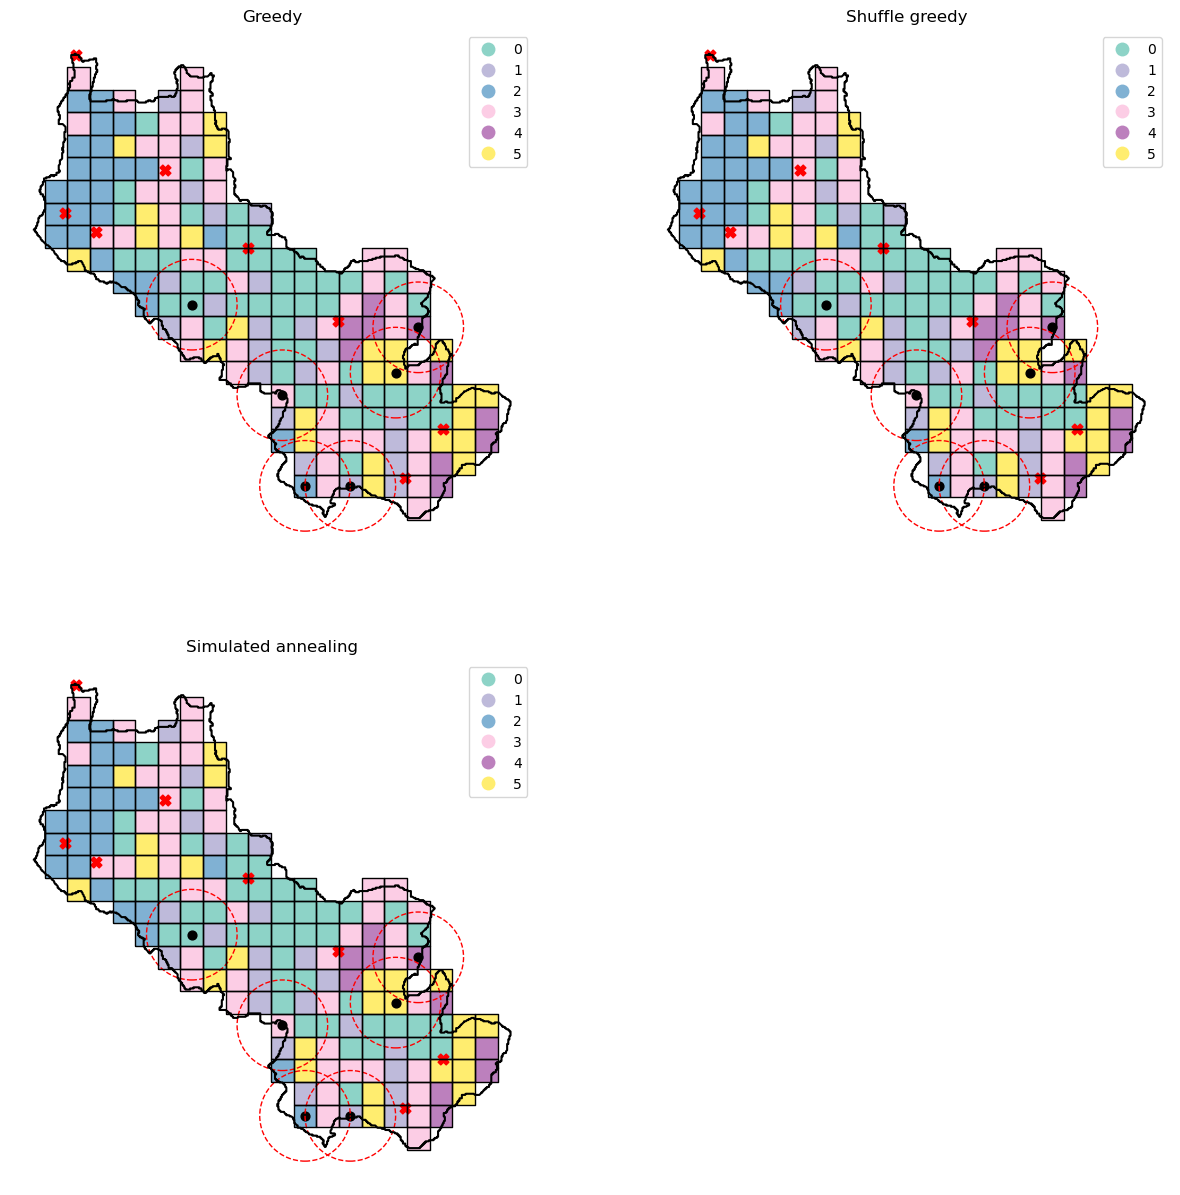

In [41]:
# PLOT
fig,axs=plt.subplots(ncols=2, nrows=2, figsize=(15,15))
axs=axs.flatten()

# #print("\n--- GREEDY ---")
plot_and_check(rainfall_gdf_merged, greedy_solution, cell_centroids, catchment_Dolwen, existing_coords, min_dist, 'Greedy',
               ax=axs[0])
axs[0].axis('off');

#print("\n--- SHUFFLE GREEDY ---")
plot_and_check(rainfall_gdf_merged, shuffle_solution, cell_centroids, catchment_Dolwen, existing_coords, min_dist, 
               'Shuffle greedy', ax=axs[1])
axs[1].axis('off');

#print("\n--- Simulated annealing ---")
plot_and_check(rainfall_gdf_merged, sa_solution, cell_centroids, catchment_Dolwen,  existing_coords, min_dist, 
               'Simulated annealing', ax=axs[2])
axs[2].axis('off');

# #print("\n--- ILP ---")
# #plot_and_check(rainfall_gdf_merged, ilp_solution_result, cell_centroids, existing_coords, min_dist, ax=axs[3])
axs[3].axis('off');
# axs[3].set_axis_off()


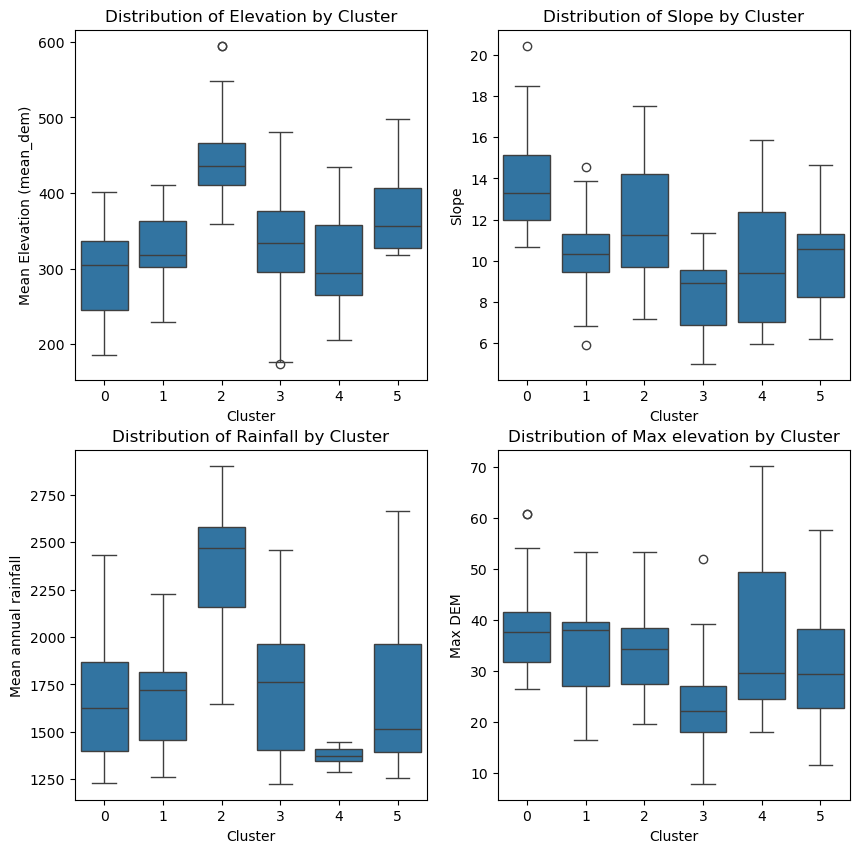

In [42]:
import seaborn as sns

fig,axs=plt.subplots(ncols=2, nrows =2, figsize=(10,10))
axs=axs.flatten()
sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_dem'], ax=axs[0])
axs[0].set_xlabel("Cluster")
axs[0].set_ylabel("Mean Elevation (mean_dem)")
axs[0].set_title("Distribution of Elevation by Cluster");

sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_slope'], ax=axs[1])
axs[1].set_xlabel("Cluster")
axs[1].set_ylabel("Slope")
axs[1].set_title("Distribution of Slope by Cluster");


sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['rainfall'], ax=axs[2])
axs[2].set_xlabel("Cluster")
axs[2].set_ylabel("Mean annual rainfall")
axs[2].set_title("Distribution of Rainfall by Cluster");

sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['std_dem'], ax=axs[3])
axs[3].set_xlabel("Cluster")
axs[3].set_ylabel("Max DEM")
axs[3].set_title("Distribution of Max elevation by Cluster");


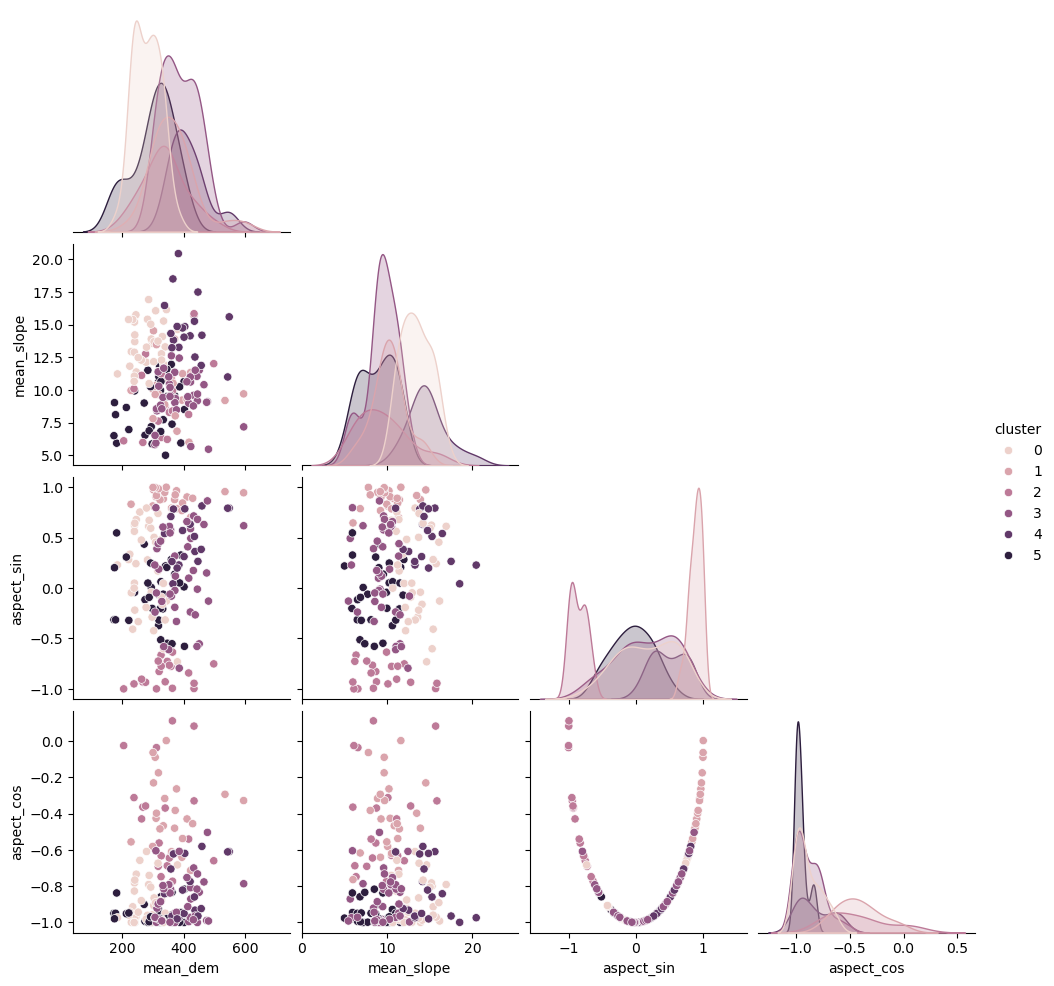

In [24]:
import seaborn as sns

sns.pairplot(rainfall_gdf_merged,vars=["mean_dem", "mean_slope", "aspect_sin", "aspect_cos"],hue="cluster",corner=True)

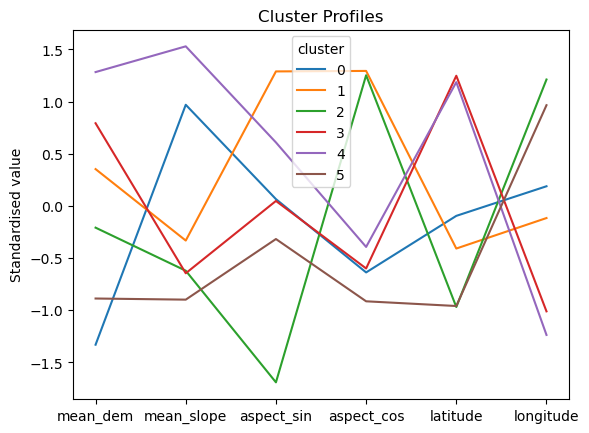

In [27]:
features = ["mean_dem", "mean_slope", "aspect_sin", "aspect_cos", 'latitude', 'longitude']

cluster_means = rainfall_gdf_merged.groupby("cluster")[features].mean()

# standardise for comparability
cluster_means_std = (cluster_means - cluster_means.mean()) / cluster_means.std()

cluster_means_std.T.plot()
plt.ylabel("Standardised value")
plt.title("Cluster Profiles")
plt.show()

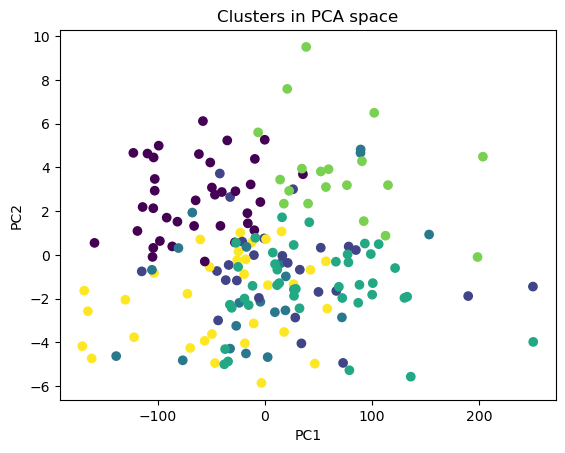

In [28]:
from sklearn.decomposition import PCA

X = rainfall_gdf_merged[["mean_dem", "mean_slope", "aspect_sin", "aspect_cos"]]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rainfall_gdf_merged["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters in PCA space")
plt.show()